# Penjadwalan Mata Kuliah dengan Coati Optimization Algorithm (COA) — **MODEL 2**
### Studi Kasus: Departemen Sistem Informasi, FILKOM Universitas Brawijaya

**Model 2 = COA + Greedy Initialization.**

Pada model ini, penugasan dosen dan penyusunan jadwal awal dilakukan secara **greedy** (heuristik konstruksi) sebelum COA berjalan. COA kemudian menggeser slot & ruang untuk meminimalkan pelanggaran. Model 1 (notebook terpisah) memakai **random initialization** sesuai paper COA asli (Eq. 1); perbandingan keduanya menjawab: *apakah greedy initialization memperbaiki hasil dibanding inisialisasi acak?*

**Unit penjadwalan** = **(Mata Kuliah, Prodi, Kelas)**. Aturan:
- Satu kelas hanya milik **satu prodi**.
- MK **wajib** (Kewajiban=1) → **4 kelas** per (MK, prodi).
- MK **minat** (Kewajiban=0) → **1 kelas** per (MK, prodi).
- MK wajib yang muncul di 2 prodi → 4+4 = 8 kelas total.
- **Praktikum**: bila `Praktikum=1`, **2 SKS diambil sebagai praktikum** (2 sesi × 50 menit di lab gedung G), sisa SKS jadi teori (ruang gedung F). Bila `Praktikum=0`, semua SKS jadi teori.
- **Dosen** dipilih dari yang **berminat** MK itu, **dahulukan Prioritas=1** (angka kecil = prioritas tinggi). Satu dosen boleh mengajar >1 kelas MK yang sama asal slot tidak bentrok.

**Constraint (Hard):** H1 konflik ruang, H2 konflik dosen, H4 overload dosen, H5 room-type mismatch, H6 istirahat, **H7 kelengkapan kelas**.
**Constraint (Soft):** S1 floor movement.

**Greedy Selection (Eq. 7 & 10 paper COA)** tetap dipakai di dalam loop COA sebagai kriteria accept-if-better; ini bagian resmi COA, terisolasi dari greedy initialization.

> Referensi COA: Dehghani, M., Montazeri, Z., Trojovská, E., & Trojovský, P. (2023). *Coati Optimization Algorithm.* Knowledge-Based Systems, 259, 110011. DOI: 10.1016/j.knosys.2022.110011.

> Tiap cell punya penjelasan utama di atasnya dan komentar per-baris. Tanda **(BARU)** / **(DIUBAH)** menandai perbedaan dari versi kode lama.

## 1. Imports

Memuat seluruh pustaka. **(DIUBAH)** ditambah `itertools` (grid parameter), `os` (folder output), dan `openpyxl` (menulis Excel multi-sheet).

In [1]:
# Pustaka standar
import time                       # mengukur execution time tiap run
import math                       # cadangan fungsi matematika
import random                     # sumber keacakan (di-seed agar reprodusibel)
import copy                       # deepcopy jadwal agar mutasi tak merusak objek asal
import os                         # (BARU) buat direktori & susun path output
import itertools                  # (BARU) bangun kombinasi grid parameter
from collections import defaultdict   # akumulasi penalti & pengelompokan

import re                         # parsing kode ruang (gedung & lantai)
import pandas as pd               # baca CSV & susun tabel hasil
import numpy as np                # argmax populasi & operasi numerik
import matplotlib.pyplot as plt   # visualisasi
from tqdm import trange           # progress bar iterasi COA
from IPython.display import display   # menampilkan DataFrame rapi

# openpyxl dipakai pandas untuk menulis Excel multi-sheet (BARU)
import openpyxl

## 3. Konfigurasi Path Output

**(BARU)** Semua hasil disimpan ke folder terpusat. **`OUTPUT_DIR` & `out_path` sengaja tetap Inggris** (konvensi path).

In [30]:
# Folder tujuan seluruh output (raw-string agar backslash Windows aman)
OUTPUT_DIR = r"D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\SALAH\Model2"

# Buat folder bila belum ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Helper path output
def out_path(filename):
    return os.path.join(OUTPUT_DIR, filename)

print("Output Model 2 disimpan ke:", OUTPUT_DIR)

Output Model 2 disimpan ke: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\SALAH\Model2


## 4. Membaca Data Mata Kuliah + Tampilkan Tiap Kolom

**(DIUBAH)** Sesuai permintaan, setiap input data ditampilkan: nama kolom, tipe data, dan contoh isi. Struktur CSV Anda: satu baris = satu pasangan (MK + dosen berminat). Kolom `Nama Dosen` berisi **id dosen** (angka), `Berminat` = peran, `Prioritas` 1/2 (1=tinggi).

In [4]:
# Baca CSV mata kuliah
mk_mentah = pd.read_csv(r"D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\data\Ganjil\data_mk_DSI_semester_ganjil.csv")

# Bersihkan spasi tepi pada nama kolom
mk_mentah.columns = [c.strip() for c in mk_mentah.columns]

# Tampilkan struktur kolom (nama + tipe data)
print("=== KOLOM DATA MATA KULIAH ===")
for kolom in mk_mentah.columns:
    print(f"  {kolom:15s} | tipe: {mk_mentah[kolom].dtype}")
print(f"\\nJumlah baris : {len(mk_mentah)}")
print(f"Kode MK unik : {mk_mentah['Kode MK'].nunique()}")
print(f"Dosen unik   : {mk_mentah['Nama Dosen'].nunique()}")

# Tampilkan contoh isi
display(mk_mentah.head())

=== KOLOM DATA MATA KULIAH ===
  Kode MK         | tipe: object
  Nama MK         | tipe: object
  Prodi MK        | tipe: object
  Prioritas       | tipe: int64
  Berminat        | tipe: object
  Nama Dosen      | tipe: int64
  SKS             | tipe: int64
  Praktikum       | tipe: int64
  Kewajiban       | tipe: int64
\nJumlah baris : 497
Kode MK unik : 87
Dosen unik   : 62


,Kode MK,Nama MK,Prodi MK,Prioritas,Berminat,Nama Dosen,SKS,Praktikum,Kewajiban
0,CSD60706,Administrasi Basis Data,Sistem Informasi,1,"Koordinator Pengelola, Pengelola, Pengampu",72,3,1,1
1,CSD60706,Administrasi Basis Data,Sistem Informasi,1,"Pengelola, Pengampu",102,3,1,1
2,CSD60706,Administrasi Basis Data,Sistem Informasi,1,Pengampu,75,3,1,1
3,CSD60706,Administrasi Basis Data,Sistem Informasi,1,Pengampu,91,3,1,1
4,CSD60706,Administrasi Basis Data,Teknologi Informasi,1,"Pengelola, Pengampu",102,3,0,0


## 5. Membaca Data Ruang Teori (Gedung F) & Lab (Gedung G) + Tampilkan Kolom

**(DIUBAH)** Aturan tegas: **ruang teori hanya gedung F, praktikum hanya gedung G**. Ruang teori dibaca dari CSV ruang kuliah lalu **disaring hanya gedung F**. Lab dibaca dari CSV lab (format `G1.2,1` → kolom1=kode ruang, kolom2=lantai); gedung diambil dari huruf pertama kode. Tiap kolom ditampilkan.

In [5]:
# --- Ruang teori (kelas) ---
ruang_mentah = pd.read_csv(r"D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\data\Ruang Kuliah.csv")
ruang_mentah.columns = [c.strip() for c in ruang_mentah.columns]

print("=== KOLOM DATA RUANG TEORI ===")
for kolom in ruang_mentah.columns:
    print(f"  {kolom:15s} | tipe: {ruang_mentah[kolom].dtype}")
display(ruang_mentah.head())

# --- Lab (praktikum) ---
lab_mentah = pd.read_csv(r"D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\data\Laboratorium.csv")
lab_mentah.columns = [c.strip() for c in lab_mentah.columns]

print("\\n=== KOLOM DATA LAB ===")
for kolom in lab_mentah.columns:
    print(f"  {kolom:15s} | tipe: {lab_mentah[kolom].dtype}")
display(lab_mentah.head())

=== KOLOM DATA RUANG TEORI ===
  kode_ruang      | tipe: object
  lokasi          | tipe: object
  lantai          | tipe: int64
  keterangan      | tipe: object


,kode_ruang,lokasi,lantai,keterangan
0,F11.1,Gedung F FILKOM,11,R. Kuliah FILKOM
1,F11.3,Gedung F FILKOM,11,R. Kuliah FILKOM
2,F11.4,Gedung F FILKOM,11,R. Kuliah FILKOM
3,F2.1,Gedung F FILKOM,2,R. Kuliah (Smart Class)
4,F2.2,Gedung F FILKOM,2,R. Kuliah (Smart Class)


\n=== KOLOM DATA LAB ===
  Kode Ruang      | tipe: object
  Lantai          | tipe: int64


,Kode Ruang,Lantai
0,G1.2,1
1,G1.3,1
2,G1.4,1
3,G1.5,1
4,G1.6,1


## 6. Parsing Ruang → Gedung, Lantai, Tipe

**(DIUBAH)** Membangun daftar ruang teori (gedung F) dan lab (gedung G). Ruang teori disaring **hanya gedung F**; lab **hanya gedung G**. Tiap ruang dicatat gedung, lantai, dan tipenya untuk keperluan constraint H5 & soft S1, serta kolom jadwal akhir.

In [6]:
# Bangun daftar ruang teori dari CSV, saring HANYA gedung F
ruang_teori = []
for kode in ruang_mentah.iloc[:, 0].astype(str):
    kode = kode.strip()
    m = re.match(r'([A-Z])(\d+)\.', kode)          # pola "F3.1" -> gedung F, lantai 3
    if m and m.group(1) == 'F':                       # HANYA gedung F untuk teori
        ruang_teori.append({'kode_ruang': kode, 'gedung': 'F',
                            'lantai': int(m.group(2)), 'tipe': 'Kelas'})

# Bangun daftar lab dari CSV (format "G1.2,1": kolom0=kode, kolom1=lantai)
ruang_lab = []
for _, row in lab_mentah.iterrows():
    kode = str(row.iloc[0]).strip()                  # kode ruang, mis. "G1.2"
    m = re.match(r'([A-Z])', kode)                    # huruf pertama = gedung
    gedung = m.group(1) if m else 'G'
    # Lantai dari kolom kedua bila ada, else parse dari kode
    try:
        lantai = int(row.iloc[1])
    except Exception:
        m2 = re.match(r'[A-Z](\d+)', kode)
        lantai = int(m2.group(1)) if m2 else 1
    if gedung == 'G':                                 # HANYA gedung G untuk praktikum
        ruang_lab.append({'kode_ruang': kode, 'gedung': 'G',
                          'lantai': lantai, 'tipe': 'Lab'})

# Himpunan kode lab untuk pengecekan cepat "apakah ruang ini lab?"
kode_lab_set = {r['kode_ruang'] for r in ruang_lab}

# Peta kode ruang -> info (gedung, lantai, tipe) untuk semua ruang
info_ruang = {}
for r in ruang_teori + ruang_lab:
    info_ruang[r['kode_ruang']] = {'gedung': r['gedung'], 'lantai': r['lantai'], 'tipe': r['tipe']}

print(f"Ruang teori (gedung F): {len(ruang_teori)}")
print(f"Lab (gedung G)        : {len(ruang_lab)}")
print(f"Total ruang terdaftar : {len(info_ruang)}")

Ruang teori (gedung F): 42
Lab (gedung G)        : 8
Total ruang terdaftar : 50


## 7. Membangun (MK, Prodi) + Daftar Dosen Berminat

**(BARU)** Dari 497 baris CSV, kita kelompokkan menjadi pasangan **(Kode MK, Prodi)** unik. Untuk tiap pasangan disimpan atribut (SKS, praktikum, kewajiban) dan **daftar dosen berminat beserta prioritasnya**. Daftar dosen ini nanti dipakai greedy untuk menugaskan kelas (dahulukan prioritas kecil).

In [7]:
# to_int aman
def to_int(x, default=0):
    try:
        return int(float(x))
    except Exception:
        return default

# Kelompokkan per (Kode MK, Prodi)
mk_prodi = {}   # (kode, prodi) -> atribut + daftar dosen berminat

for _, row in mk_mentah.iterrows():
    kode  = str(row['Kode MK']).strip()
    prodi = str(row['Prodi MK']).strip()
    key = (kode, prodi)

    # Bila pasangan belum ada, inisialisasi atributnya
    if key not in mk_prodi:
        mk_prodi[key] = {
            'kode'     : kode,
            'nama'     : str(row['Nama MK']).strip(),
            'prodi'    : prodi,
            'sks'      : to_int(row['SKS']),
            'praktikum': to_int(row['Praktikum']),
            'kewajiban': to_int(row['Kewajiban']),   # 1=wajib, 0=minat
            'dosen_berminat': [],                     # akan diisi (id_dosen, prioritas)
        }
    # Tambahkan dosen berminat + prioritasnya (1=tinggi, 2=rendah)
    id_dosen  = to_int(row['Nama Dosen'], default=None)
    prioritas = to_int(row['Prioritas'], default=2)
    if id_dosen is not None:
        mk_prodi[key]['dosen_berminat'].append((id_dosen, prioritas))

# Ringkasan
n_wajib = sum(1 for v in mk_prodi.values() if v['kewajiban'] == 1)
n_minat = sum(1 for v in mk_prodi.values() if v['kewajiban'] == 0)
print(f"Pasangan (MK, prodi) : {len(mk_prodi)}")
print(f"  wajib : {n_wajib}  (-> 4 kelas each)")
print(f"  minat : {n_minat}  (-> 1 kelas each)")

# Tampilkan satu contoh
contoh = list(mk_prodi.items())[0]
print(f"\nContoh: {contoh[0]}")
for k, v in contoh[1].items():
    print(f"  {k}: {v}")

Pasangan (MK, prodi) : 117
  wajib : 65  (-> 4 kelas each)
  minat : 52  (-> 1 kelas each)

Contoh: ('CSD60706', 'Sistem Informasi')
  kode: CSD60706
  nama: Administrasi Basis Data
  prodi: Sistem Informasi
  sks: 3
  praktikum: 1
  kewajiban: 1
  dosen_berminat: [(72, 1), (102, 1), (75, 1), (91, 1)]


## 8. Greedy Initialization — Tahap Struktur Kelas & Penugasan Dosen

Untuk tiap (MK, prodi): tentukan jumlah kelas (wajib→4, minat→1), lalu tugaskan dosen ke tiap kelas secara **greedy**:
- Urutkan dosen berminat berdasarkan **prioritas** (kecil dulu = prioritas tinggi).
- Tugaskan dosen ke kelas satu per satu; bila kelas > dosen, **ulang dari awal** (1 dosen boleh >1 kelas MK sama).
- Bentuk sesi tiap kelas: bila praktikum, **2 SKS praktikum** (2 sesi lab) + sisa teori; else semua teori.

Hasilnya struktur `kelas_list` — daftar semua kelas dengan dosen sudah **tetap** (fix). Ini yang membedakan Model 2: dosen tidak lagi menjadi variabel COA.

In [8]:
# Konstanta durasi
SKS_DURATION = 50    # 1 SKS = 50 menit
PRAK_SKS     = 2     # 2 SKS pertama jadi praktikum bila MK praktikum

def bangun_kelas():
    """Bangun semua kelas + tugaskan dosen greedy. Return list kelas."""
    kelas_list = []                       # daftar seluruh kelas
    kelas_id = 0                          # penomoran unik kelas

    # Iterasi tiap (MK, prodi), urut agar deterministik
    for key in sorted(mk_prodi.keys()):
        mk = mk_prodi[key]
        # Jumlah kelas: wajib=4, minat=1
        n_kelas = 4 if mk['kewajiban'] == 1 else 1

        # Urutkan dosen berminat berdasar prioritas (kecil=tinggi); ambil id-nya saja
        dosen_urut = [d for (d, p) in sorted(mk['dosen_berminat'], key=lambda x: x[1])]
        if not dosen_urut:                # jaga-jaga bila tak ada dosen (seharusnya tak terjadi)
            dosen_urut = [None]

        # Tugaskan dosen ke tiap kelas (ulang bila kelas > dosen)
        for c in range(n_kelas):
            dosen = dosen_urut[c % len(dosen_urut)]   # putar bila dosen habis
            label_kelas = chr(ord('A') + c)           # A, B, C, D

            # Bentuk sesi kelas ini
            sesi_list = []
            sks = mk['sks']
            if mk['praktikum'] == 1:
                # 2 SKS praktikum (2 sesi lab)
                for _ in range(min(PRAK_SKS, sks)):
                    sesi_list.append({'tipe': 'practicum', 'slot': None, 'ruang': None})
                # sisa SKS jadi teori
                for _ in range(max(0, sks - PRAK_SKS)):
                    sesi_list.append({'tipe': 'lecture', 'slot': None, 'ruang': None})
            else:
                # semua SKS jadi teori
                for _ in range(sks):
                    sesi_list.append({'tipe': 'lecture', 'slot': None, 'ruang': None})

            # Simpan kelas
            kelas_list.append({
                'id'       : kelas_id,
                'kode'     : mk['kode'],
                'nama'     : mk['nama'],
                'prodi'    : mk['prodi'],
                'kelas'    : label_kelas,
                'kewajiban': mk['kewajiban'],
                'sks'      : sks,
                'dosen'    : dosen,           # DOSEN FIX (hasil greedy) — tidak diubah COA
                'sesi'     : sesi_list,
            })
            kelas_id += 1

    return kelas_list

# Bangun struktur kelas (dosen sudah fix)
kelas_list = bangun_kelas()

# Ringkasan
total_sesi = sum(len(k['sesi']) for k in kelas_list)
print(f"Total kelas : {len(kelas_list)}")
print(f"Total sesi  : {total_sesi}")
# Tampilkan contoh
print("\nContoh 2 kelas pertama:")
for k in kelas_list[:2]:
    print(f"  {k['kode']} {k['prodi']} kelas {k['kelas']} | dosen={k['dosen']} | "
          f"{len(k['sesi'])} sesi ({sum(1 for s in k['sesi'] if s['tipe']=='practicum')} prak)")

Total kelas : 312
Total sesi  : 864

Contoh 2 kelas pertama:
  CIE61101 Pendidikan Teknologi Informasi kelas A | dosen=39 | 3 sesi (0 prak)
  CIE61101 Pendidikan Teknologi Informasi kelas B | dosen=39 | 3 sesi (0 prak)


## 9. Parameter Waktu & Pembangkitan Slot (`rebuild_slots`)

**(BARU)** Slot dibangun dengan interval yang dapat diatur (variabel uji Skenario 1). Jam operasional 07:00–17:50, sesi 50 menit. **Istirahat tidak memblok slot** — pelanggaran istirahat (H6) dihitung saat evaluasi, agar terukur. Fungsi `rebuild_slots(interval)` membangun ulang seluruh struktur slot.

In [9]:
# Hari kerja & batas jam operasional (menit sejak 00:00)
DAYS          = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
DAY_START_MIN = 7 * 60          # 07:00
DAY_END_MIN   = 17 * 60 + 50    # 17:50

# Jam istirahat per hari (untuk MENGHITUNG H6, bukan memblok slot)
BREAKS_MIN = {
    'Mon': [(11*60, 12*60)], 'Tue': [(11*60, 12*60)], 'Wed': [(11*60, 12*60)],
    'Thu': [(11*60, 12*60)], 'Fri': [(11*60, 13*60)],
}

def kena_istirahat(start_min, durasi, hari):
    # True bila sesi [start, start+durasi) menabrak salah satu blok istirahat hari itu
    end_min = start_min + durasi
    for b_start, b_end in BREAKS_MIN[hari]:
        if start_min < b_end and end_min > b_start:
            return True
    return False

def rebuild_slots(interval=50):
    # Bangun ulang variabel slot global untuk interval tertentu
    global SLOT_INTERVAL, slots_tersedia, INDEX_SLOT
    SLOT_INTERVAL = interval
    s = []
    for d in DAYS:                                    # tiap hari
        t = DAY_START_MIN                             # mulai 07:00
        while t + SKS_DURATION <= DAY_END_MIN:        # sesi harus selesai <= 17:50
            s.append((d, t // 60, t % 60))            # simpan (hari, jam, menit)
            t += interval                             # geser sebesar interval
    slots_tersedia = list(dict.fromkeys(s))           # buang duplikat, jaga urutan
    INDEX_SLOT = {sl: i for i, sl in enumerate(slots_tersedia)}
    return slots_tersedia

# Bangun slot awal (interval default 50 menit)
rebuild_slots(50)
print(f"Interval slot : {SLOT_INTERVAL} menit")
print(f"Total slot    : {len(slots_tersedia)}")
print(f"Contoh slot   : {slots_tersedia[:4]}")

Interval slot : 50 menit
Total slot    : 65
Contoh slot   : [('Mon', 7, 0), ('Mon', 7, 50), ('Mon', 8, 40), ('Mon', 9, 30)]


## 10. Fungsi Overlap Dua Sesi

Mengecek apakah dua sesi 50 menit beririsan waktu pada hari sama. Dipakai deteksi konflik ruang (H1) & dosen (H2).

In [10]:
def sesi_overlap(slot_a, slot_b):
    # Bongkar tuple slot
    ha, jam_a, mnt_a = slot_a
    hb, jam_b, mnt_b = slot_b
    if ha != hb:                       # beda hari -> tak mungkin overlap
        return False
    start_a = jam_a * 60 + mnt_a
    start_b = jam_b * 60 + mnt_b
    # Overlap bila saling menembus interval 50 menit
    return start_a < start_b + SKS_DURATION and start_b < start_a + SKS_DURATION

## 11. Kandidat Ruang per Tipe Sesi

Sesi teori → ruang gedung F; sesi praktikum → lab gedung G. Menjamin aturan gedung sejak pemilihan kandidat.

In [11]:
# Daftar kode ruang per tipe sesi
kandidat_ruang = {
    'lecture'  : [r['kode_ruang'] for r in ruang_teori],   # teori -> gedung F
    'practicum': [r['kode_ruang'] for r in ruang_lab],     # praktikum -> gedung G
}
print("Kandidat ruang teori    :", len(kandidat_ruang['lecture']))
print("Kandidat ruang praktikum:", len(kandidat_ruang['practicum']))

Kandidat ruang teori    : 42
Kandidat ruang praktikum: 8


## 12. Greedy Initialization — Tahap Jadwal Awal (slot + ruang)

**(BARU)** Menempatkan tiap sesi ke kombinasi (slot, ruang) yang **paling sepi** sambil menghindari overlap ruang & dosen bila mungkin. Menghasilkan `greedy_schedule()` — solusi awal berkualitas (baseline Model 2). Dosen sudah fix dari cell 8, jadi hanya slot & ruang yang diisi di sini.

**Nama fungsi `greedy_schedule` sengaja tetap Inggris** (bagian nama fungsi inti yang dikecualikan).

In [12]:
def greedy_schedule():
    # Salin struktur kelas agar objek asal tak ternodai antar-run
    jadwal = copy.deepcopy(kelas_list)

    # Pelacak pemakaian untuk strategi "paling sepi" + hindari konflik
    pakai_count = defaultdict(int)     # (slot, ruang) -> berapa kali dipakai
    ruang_pakai = defaultdict(list)    # ruang -> [slot, ...]
    dosen_pakai = defaultdict(list)    # dosen -> [slot, ...]

    # Kumpulkan semua sesi (kelas_idx, sesi_idx), praktikum didahulukan (lebih langka)
    semua_sesi = []
    for ki, k in enumerate(jadwal):
        for si, s in enumerate(k['sesi']):
            semua_sesi.append((ki, si, 0 if s['tipe'] == 'practicum' else 1))
    semua_sesi.sort(key=lambda x: x[2])   # praktikum (0) dulu

    # Tempatkan tiap sesi
    for (ki, si, _) in semua_sesi:
        k = jadwal[ki]
        s = k['sesi'][si]
        dosen = k['dosen']
        rlist = kandidat_ruang[s['tipe']]

        # Sampel kandidat agar cepat (tak menyapu seluruh kombinasi)
        slot_sample = random.sample(range(len(slots_tersedia)),
                                    min(40, len(slots_tersedia)))
        room_sample = rlist if len(rlist) <= 8 else random.sample(rlist, 8)

        best = None; best_score = None
        for idx in slot_sample:
            stup = slots_tersedia[idx]
            for room in room_sample:
                # Penalti konflik besar, kepadatan kecil (agar menyebar)
                konflik = 0
                if any(sesi_overlap(stup, rs) for rs in ruang_pakai[room]):
                    konflik += 100
                if dosen is not None and any(sesi_overlap(stup, ds) for ds in dosen_pakai[dosen]):
                    konflik += 100
                score = konflik + pakai_count[(stup, room)]
                if best_score is None or score < best_score:
                    best_score = score; best = (idx, room)

        # Terapkan pilihan terbaik
        idx, room = best
        s['slot'] = idx
        s['ruang'] = room
        stup = slots_tersedia[idx]
        pakai_count[(stup, room)] += 1
        ruang_pakai[room].append(stup)
        if dosen is not None:
            dosen_pakai[dosen].append(stup)

    return jadwal

## 13. Random Schedule & Repair (untuk mutasi populasi)

`random_schedule` mengisi slot/ruang acak; `repair_schedule` menyelesaikan konflik overlap. Dipakai untuk membuat variasi populasi (greedy termutasi) dan setelah operator COA. **Nama `random_schedule` & `repair_schedule` tetap Inggris** (fungsi inti dikecualikan).

In [13]:
def random_schedule():
    # Salin struktur kelas
    jadwal = copy.deepcopy(kelas_list)
    # Isi tiap sesi dengan slot & ruang acak sesuai tipe
    for k in jadwal:
        for s in k['sesi']:
            s['slot'] = random.randrange(len(slots_tersedia))
            rlist = kandidat_ruang[s['tipe']]
            s['ruang'] = random.choice(rlist) if rlist else None
    return jadwal


def repair_schedule(jadwal):
    # Pelacak slot terpakai per ruang & dosen
    ruang_pakai = defaultdict(list)
    dosen_pakai = defaultdict(list)
    for k in jadwal:
        dosen = k['dosen']
        for s in k['sesi']:
            rlist = kandidat_ruang[s['tipe']]
            # Pastikan slot & ruang valid
            if s['slot'] is None or s['slot'] >= len(slots_tersedia):
                s['slot'] = random.randrange(len(slots_tersedia))
            if s['ruang'] is None and rlist:
                s['ruang'] = random.choice(rlist)
            # Coba hingga 30x cari slot bebas konflik ruang & dosen
            for _ in range(30):
                stup = slots_tersedia[s['slot']]
                konflik_ruang = any(sesi_overlap(stup, rs) for rs in ruang_pakai[s['ruang']])
                konflik_dosen = (dosen is not None and
                                 any(sesi_overlap(stup, ds) for ds in dosen_pakai[dosen]))
                if not konflik_ruang and not konflik_dosen:
                    break
                s['slot'] = random.randrange(len(slots_tersedia))
            # Catat slot final
            stup = slots_tersedia[s['slot']]
            ruang_pakai[s['ruang']].append(stup)
            if dosen is not None:
                dosen_pakai[dosen].append(stup)
    return jadwal

## 14. Evaluasi Jadwal — Constraint Final Model 2

**(BARU).** Menghitung seluruh pelanggaran. **Nama fungsi penalty & variabel `heavy_penalty`/`soft_penalty` sengaja tetap Inggris** (dikecualikan sesuai permintaan).

**HARD:**
- **H1 `H1_room_conflict`** — dua sesi overlap di ruang sama.
- **H2 `H2_lecturer_conflict`** — dua sesi overlap pada dosen sama.
- **H3 `H4_lecturer_overload`** — total menit mengajar dosen > `MAX_MENIT_DOSEN`/pekan.
- **H4 `H5_room_type_mismatch`** — teori di lab / praktikum bukan di lab.
- **H5 `H6_lunch_break`** — sesi menabrak jam istirahat.
- **H6 `H7_class_completeness`** *(BARU)* — kelengkapan kelas: karena struktur kelas sudah dibangun benar di Tahap greedy (wajib=4, minat=1), H7 memverifikasi tiap sesi punya slot & ruang valid. Bila ada sesi tak lengkap, dihukum.

**SOFT:**
- **S1 `S1_floor_movement`** — dosen berpindah gedung/lantai antar sesi berurutan pada hari sama.

Constraint dihitung ke dua akumulator: `heavy_penalty` dan `soft_penalty`.

In [14]:
# Batas atas beban dosen per pekan (menit)
MAX_MENIT_DOSEN = 2400

def evaluate_schedule_detailed(jadwal):
    # Akumulator pelanggaran (nama constraint -> jumlah)
    heavy_penalty = defaultdict(int)
    soft_penalty  = defaultdict(int)

    # Struktur bantu
    ruang_sesi   = defaultdict(list)   # ruang -> [slot, ...]        (H1)
    dosen_sesi   = defaultdict(list)   # dosen -> [slot, ...]        (H2)
    dosen_menit  = defaultdict(int)    # dosen -> total menit        (H3)
    dosen_hari   = defaultdict(list)   # (dosen, hari) -> [(start, ruang), ...] (S1)

    # ---- Iterasi tiap kelas & sesi ----
    for k in jadwal:
        dosen = k['dosen']
        # Akumulasi beban dosen (tiap sesi = SKS_DURATION menit) untuk H3
        if dosen is not None:
            dosen_menit[dosen] += len(k['sesi']) * SKS_DURATION

        for s in k['sesi']:
            # H6: sesi harus punya slot & ruang valid (kelengkapan kelas)
            if s['slot'] is None or s['ruang'] is None:
                heavy_penalty['H6_class_completeness'] += 1
                continue

            slot = slots_tersedia[s['slot']]
            hari, jam, menit = slot
            start_min = jam * 60 + menit

            # H4: teori tak boleh di lab; praktikum harus di lab (room type mismatch)
            if s['tipe'] == 'lecture' and s['ruang'] in kode_lab_set:
                heavy_penalty['H4_room_type_mismatch'] += 1
            if s['tipe'] == 'practicum' and s['ruang'] not in kode_lab_set:
                heavy_penalty['H4_room_type_mismatch'] += 1

            # H5: sesi menabrak istirahat (lunch break)
            if kena_istirahat(start_min, SKS_DURATION, hari):
                heavy_penalty['H5_lunch_break'] += 1

            # Kumpulkan untuk cek overlap
            ruang_sesi[s['ruang']].append(slot)          # H1
            if dosen is not None:
                dosen_sesi[dosen].append(slot)           # H2
                dosen_hari[(dosen, hari)].append((start_min, s['ruang']))   # S1

    # ---- H1: overlap antar sesi di ruang sama (konflik ruang) ----
    for room, lst in ruang_sesi.items():
        for a in range(len(lst)):
            for b in range(a + 1, len(lst)):
                if sesi_overlap(lst[a], lst[b]):
                    heavy_penalty['H1_room_conflict'] += 1

    # ---- H2: overlap antar sesi dosen sama (konflik dosen) ----
    for d, lst in dosen_sesi.items():
        for a in range(len(lst)):
            for b in range(a + 1, len(lst)):
                if sesi_overlap(lst[a], lst[b]):
                    heavy_penalty['H2_lecturer_conflict'] += 1

    # ---- H3: overload dosen (beban di atas batas atas) ----
    for d, menit in dosen_menit.items():
        if menit > MAX_MENIT_DOSEN:
            heavy_penalty['H3_lecturer_overload'] += (menit - MAX_MENIT_DOSEN) // SKS_DURATION

    # ---- S1: perpindahan gedung/lantai antar sesi berurutan (floor movement) ----
    for (d, hari), lst in dosen_hari.items():
        lst.sort(key=lambda x: x[0])                     # urut berdasar waktu mulai
        for i in range(len(lst) - 1):
            ra, rb = lst[i][1], lst[i + 1][1]
            ia, ib = info_ruang.get(ra, {}), info_ruang.get(rb, {})
            if ia.get('gedung') != ib.get('gedung') or ia.get('lantai') != ib.get('lantai'):
                soft_penalty['S1_floor_movement'] += 1

    # Total
    total_heavy = sum(heavy_penalty.values())
    total_soft  = sum(soft_penalty.values())

    return {
        'heavy_total'  : total_heavy,
        'soft_total'   : total_soft,
        'heavy_detail' : dict(heavy_penalty),
        'soft_detail'  : dict(soft_penalty),
        'is_feasible'  : total_heavy == 0,   # feasible bila tak ada pelanggaran hard
    } 

In [15]:
# # Batas atas beban dosen per pekan (menit)
# MAX_MENIT_DOSEN = 2400

# def evaluate_schedule_detailed(jadwal):
#     # Akumulator pelanggaran (nama constraint -> jumlah)
#     heavy_penalty = defaultdict(int)
#     soft_penalty  = defaultdict(int)

#     # Struktur bantu
#     ruang_sesi   = defaultdict(list)   # ruang -> [slot, ...]        (H1)
#     dosen_sesi   = defaultdict(list)   # dosen -> [slot, ...]        (H2)
#     dosen_menit  = defaultdict(int)    # dosen -> total menit        (H4)
#     dosen_hari   = defaultdict(list)   # (dosen, hari) -> [(start, ruang), ...] (S1)

#     # ---- Iterasi tiap kelas & sesi ----
#     for k in jadwal:
#         dosen = k['dosen']
#         # Akumulasi beban dosen (tiap sesi = SKS_DURATION menit) untuk H4
#         if dosen is not None:
#             dosen_menit[dosen] += len(k['sesi']) * SKS_DURATION

#         for s in k['sesi']:
#             # H7: sesi harus punya slot & ruang valid
#             if s['slot'] is None or s['ruang'] is None:
#                 heavy_penalty['H7_class_completeness'] += 1
#                 continue

#             slot = slots_tersedia[s['slot']]
#             hari, jam, menit = slot
#             start_min = jam * 60 + menit

#             # H5: teori tak boleh di lab; praktikum harus di lab
#             if s['tipe'] == 'lecture' and s['ruang'] in kode_lab_set:
#                 heavy_penalty['H5_room_type_mismatch'] += 1
#             if s['tipe'] == 'practicum' and s['ruang'] not in kode_lab_set:
#                 heavy_penalty['H5_room_type_mismatch'] += 1

#             # H6: sesi menabrak istirahat
#             if kena_istirahat(start_min, SKS_DURATION, hari):
#                 heavy_penalty['H6_lunch_break'] += 1

#             # Kumpulkan untuk cek overlap
#             ruang_sesi[s['ruang']].append(slot)          # H1
#             if dosen is not None:
#                 dosen_sesi[dosen].append(slot)           # H2
#                 dosen_hari[(dosen, hari)].append((start_min, s['ruang']))   # S1

#     # ---- H1: overlap antar sesi di ruang sama ----
#     for room, lst in ruang_sesi.items():
#         for a in range(len(lst)):
#             for b in range(a + 1, len(lst)):
#                 if sesi_overlap(lst[a], lst[b]):
#                     heavy_penalty['H1_room_conflict'] += 1

#     # ---- H2: overlap antar sesi dosen sama ----
#     for d, lst in dosen_sesi.items():
#         for a in range(len(lst)):
#             for b in range(a + 1, len(lst)):
#                 if sesi_overlap(lst[a], lst[b]):
#                     heavy_penalty['H2_lecturer_conflict'] += 1

#     # ---- H4: overload dosen (di atas batas atas) ----
#     for d, menit in dosen_menit.items():
#         if menit > MAX_MENIT_DOSEN:
#             heavy_penalty['H4_lecturer_overload'] += (menit - MAX_MENIT_DOSEN) // SKS_DURATION

#     # ---- S1: perpindahan gedung/lantai antar sesi berurutan ----
#     for (d, hari), lst in dosen_hari.items():
#         lst.sort(key=lambda x: x[0])                     # urut berdasar waktu mulai
#         for i in range(len(lst) - 1):
#             ra, rb = lst[i][1], lst[i + 1][1]
#             ia, ib = info_ruang.get(ra, {}), info_ruang.get(rb, {})
#             if ia.get('gedung') != ib.get('gedung') or ia.get('lantai') != ib.get('lantai'):
#                 soft_penalty['S1_floor_movement'] += 1

#     # Total
#     total_heavy = sum(heavy_penalty.values())
#     total_soft  = sum(soft_penalty.values())

#     return {
#         'heavy_total'  : total_heavy,
#         'soft_total'   : total_soft,
#         'heavy_detail' : dict(heavy_penalty),
#         'soft_detail'  : dict(soft_penalty),
#         'is_feasible'  : total_heavy == 0,   # feasible bila tak ada pelanggaran hard
#     }

## 15. Fitness Score

Menghitung `penalty` (cost, kecil=baik) dan `fitness` (normalisasi, besar=baik untuk seleksi COA). **Nama fungsi & variabel bobot tetap Inggris.**

In [16]:
# Bobot pelanggaran (hard jauh lebih besar dari soft)
W_HEAVY = 1000   # bobot tiap pelanggaran hard
W_SOFT  = 10     # bobot tiap pelanggaran soft

def fitness_score(jadwal):
    ev = evaluate_schedule_detailed(jadwal)
    # penalty = cost (kecil=baik)
    penalty = ev['heavy_total'] * W_HEAVY + ev['soft_total'] * W_SOFT
    ev['penalty'] = penalty
    # fitness = normalisasi (besar=baik) untuk kriteria seleksi COA
    ev['fitness'] = 1.0 / (1.0 + penalty)
    return ev

## 16. Operator COA (Eq. 4, 5-6, 8-9)

**(BARU).** Tiga operator sesuai paper COA. **Nama fungsi `coati_explore_best`, `coati_explore_random`, `coati_exploit_local` tetap Inggris** (dikecualikan). Sesuai paper, tiap operator memperbarui **seluruh sesi** (`move_frac=1.0` = setia Eq. 4/6/9 yang memperbarui semua dimensi). Isi/variabel lokal memakai Bahasa Indonesia.

- **`coati_explore_best`** (Eq. 4): eksplorasi menuju iguana = Xbest. `I ∈ {1,2}` acak; I=1 mendekat, I=2 menjauh.
- **`coati_explore_random`** (Eq. 5-6): iguana di posisi acak; dekati bila lebih baik, jauhi bila tidak.
- **`coati_exploit_local`** (Eq. 8-9): eksploitasi lokal; radius menyempit seiring iterasi.

Dosen TIDAK diubah operator (fix dari greedy) — hanya slot & ruang.

In [17]:
# Ambil sesi yang akan digerakkan (default: SEMUA sesi, sesuai paper)
def _ambil_sesi(jadwal, move_frac):
    pool = [(ki, si) for ki, k in enumerate(jadwal) for si in range(len(k['sesi']))]
    if move_frac >= 1.0:
        return pool                                   # semua sesi (setia paper)
    n = max(1, int(len(pool) * move_frac))
    return random.sample(pool, n)


def coati_explore_best(curr, best, move_frac=1.0):
    # Salin individu
    baru = copy.deepcopy(curr)
    # Untuk tiap sesi: tarik ke Xbest (I=1) atau menjauh acak (I=2)  [Eq. 4]
    for (ki, si) in _ambil_sesi(baru, move_frac):
        I = random.randint(1, 2)                       # I in {1,2}
        if I == 1:
            # Mendekati iguana (Xbest): salin slot & ruang terbaik
            baru[ki]['sesi'][si]['slot'] = best[ki]['sesi'][si]['slot']
            baru[ki]['sesi'][si]['ruang'] = best[ki]['sesi'][si]['ruang']
        else:
            # Menjauh: slot & ruang acak sesuai tipe
            tipe = baru[ki]['sesi'][si]['tipe']
            baru[ki]['sesi'][si]['slot'] = random.randrange(len(slots_tersedia))
            rlist = kandidat_ruang[tipe]
            if rlist:
                baru[ki]['sesi'][si]['ruang'] = random.choice(rlist)
    return baru


def coati_explore_random(curr, move_frac=1.0):
    # Salin individu & bangun "iguana" acak untuk dibandingkan
    baru = copy.deepcopy(curr)
    iguana = copy.deepcopy(baru)
    picked = _ambil_sesi(baru, move_frac)
    for (ki, si) in picked:
        tipe = iguana[ki]['sesi'][si]['tipe']
        iguana[ki]['sesi'][si]['slot'] = random.randrange(len(slots_tersedia))
        rlist = kandidat_ruang[tipe]
        if rlist:
            iguana[ki]['sesi'][si]['ruang'] = random.choice(rlist)

    # Bandingkan fitness posisi sekarang vs iguana  [Eq. 5-6]
    fit_curr   = fitness_score(baru)['fitness']
    fit_iguana = fitness_score(iguana)['fitness']

    for (ki, si) in picked:
        tipe = baru[ki]['sesi'][si]['tipe']
        rlist = kandidat_ruang[tipe]
        if fit_iguana > fit_curr:
            # Iguana lebih baik -> dekati
            baru[ki]['sesi'][si]['slot'] = iguana[ki]['sesi'][si]['slot']
            baru[ki]['sesi'][si]['ruang'] = iguana[ki]['sesi'][si]['ruang']
        else:
            # Iguana lebih buruk -> menjauh (acak)
            baru[ki]['sesi'][si]['slot'] = random.randrange(len(slots_tersedia))
            if rlist:
                baru[ki]['sesi'][si]['ruang'] = random.choice(rlist)
    return baru


def coati_exploit_local(curr, max_perturb, move_frac=1.0):
    # Salin individu
    baru = copy.deepcopy(curr)
    n_slots = len(slots_tersedia)
    # Perturbasi lokal: geser slot dalam radius yang menyempit  [Eq. 8-9]
    for (ki, si) in _ambil_sesi(baru, move_frac):
        pos = baru[ki]['sesi'][si]['slot']
        lo = max(0, pos - max_perturb)
        hi = min(n_slots - 1, pos + max_perturb)
        baru[ki]['sesi'][si]['slot'] = random.randint(lo, hi)
        # Sesekali geser ruang juga agar tak macet
        if random.random() < 0.3:
            rlist = kandidat_ruang[baru[ki]['sesi'][si]['tipe']]
            if rlist:
                baru[ki]['sesi'][si]['ruang'] = random.choice(rlist)
    return baru

## 17. Mutasi Jadwal (untuk keragaman populasi)

Membuat variasi dari solusi greedy agar populasi awal tidak seragam. Hanya slot & ruang yang dimutasi; dosen tetap.

In [18]:
def mutate_schedule(base, frac=0.2):
    # Salin basis
    baru = copy.deepcopy(base)
    # Pilih ~frac sesi untuk dimutasi acak
    pool = [(ki, si) for ki, k in enumerate(baru) for si in range(len(k['sesi']))]
    for (ki, si) in random.sample(pool, max(1, int(len(pool) * frac))):
        tipe = baru[ki]['sesi'][si]['tipe']
        baru[ki]['sesi'][si]['slot'] = random.randrange(len(slots_tersedia))
        rlist = kandidat_ruang[tipe]
        if rlist:
            baru[ki]['sesi'][si]['ruang'] = random.choice(rlist)
    return baru

## 18. Algoritma Utama COA — Model 1 (Greedy Initialization)

**(BARU).** Alur sesuai Algorithm 1 paper, dengan **inisialisasi greedy** (ciri Model 1):

1. `Coati[0] = greedy_schedule()` (solusi greedy); sisanya = greedy termutasi + repair.
2. **`initial_penalty`** = evaluasi solusi greedy sebelum optimasi (baseline untuk Skenario 2).
3. Tiap iterasi: Fase 1a (Eq. 4) → Fase 1b (Eq. 5-6) → Fase 2 (Eq. 8-9).
4. **Greedy Selection (Eq. 7 & 10):** kandidat baru diterima **hanya bila fitness lebih baik**. Ini bagian resmi COA, terisolasi sebagai accept/reject.
5. Mengembalikan solusi terbaik + `initial_eval` (baseline) + history konvergensi.

Fungsi menerima `checkpoint_path` agar konvergensi tiap iterasi ditulis langsung (anti-hilang).

In [19]:
def coati_optimization(iterations, pop_size, move_frac=1.0,
                       checkpoint_path=None, show_progress=True):
    # ---- Inisialisasi GREEDY (ciri Model 1) ----
    greedy0 = greedy_schedule()                        # solusi awal greedy
    initial_eval = fitness_score(copy.deepcopy(greedy0))   # BASELINE (Skenario 2)

    population = [greedy0]                              # individu-0 = greedy murni
    for _ in range(pop_size - 1):                      # sisanya = greedy termutasi + repair
        population.append(repair_schedule(mutate_schedule(greedy0, frac=0.2)))

    # Evaluasi populasi awal
    evals = [fitness_score(p) for p in population]

    # Xbest awal
    idx0 = int(np.argmax([e['fitness'] for e in evals]))
    best = copy.deepcopy(population[idx0])
    best_eval = evals[idx0]

    # History konvergensi
    history = {'fitness': [], 'penalty': [], 'heavy': [], 'soft': []}
    half = pop_size // 2
    start = time.time()

    # Header checkpoint (ditulis langsung agar anti-hilang)
    if checkpoint_path:
        with open(checkpoint_path, 'w') as f:
            f.write("iterasi,fitness,penalty,heavy_total,soft_total,feasible,execution_time_s\n")

    loop = trange(1, iterations + 1, desc="COA-M1") if show_progress else range(1, iterations + 1)

    for t in loop:
        # Update Xbest di awal iterasi
        idx = int(np.argmax([e['fitness'] for e in evals]))
        if evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(population[idx]); best_eval = evals[idx]

        # Fase 1a: kelompok 1 -> eksplorasi ke Xbest (Eq. 4)
        for i in range(half):
            cand = repair_schedule(coati_explore_best(population[i], best, move_frac))
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i]['fitness']:          # GREEDY SELECTION (Eq. 7)
                population[i], evals[i] = cand, ev

        # Fase 1b: kelompok 2 -> eksplorasi iguana acak (Eq. 5-6)
        for i in range(half, pop_size):
            cand = repair_schedule(coati_explore_random(population[i], move_frac))
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i]['fitness']:          # GREEDY SELECTION (Eq. 7)
                population[i], evals[i] = cand, ev

        # Radius eksploitasi menyempit seiring iterasi
        max_perturb = max(1, int(len(slots_tersedia) / t))

        # Fase 2: eksploitasi lokal (Eq. 8-9)
        for i in range(pop_size):
            cand = repair_schedule(coati_exploit_local(population[i], max_perturb, move_frac))
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i]['fitness']:          # GREEDY SELECTION (Eq. 10)
                population[i], evals[i] = cand, ev

        # Simpan best & history
        idx = int(np.argmax([e['fitness'] for e in evals]))
        if evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(population[idx]); best_eval = evals[idx]

        history['fitness'].append(best_eval['fitness'])
        history['penalty'].append(best_eval['penalty'])
        history['heavy'].append(best_eval['heavy_total'])
        history['soft'].append(best_eval['soft_total'])

        # Checkpoint per iterasi (anti-hilang)
        if checkpoint_path:
            with open(checkpoint_path, 'a') as f:
                f.write(f"{t},{best_eval['fitness']:.8f},{best_eval['penalty']},"
                        f"{best_eval['heavy_total']},{best_eval['soft_total']},"
                        f"{best_eval['is_feasible']},{round(time.time()-start,2)}\n")

    execution_time = time.time() - start
    return best, best_eval, initial_eval, {'history': history, 'execution_time': execution_time}

# 19. Rancangan Eksperimen — Skenario 1 & 2

**(BARU).** Variabel uji parameter COA:
- `population` ∈ {30, 50} — parameter COA resmi (N)
- `max_iter` ∈ {300, 500, 1000} — parameter COA resmi (T)
- `slot_interval` ∈ {50} — parameter representasi (granularitas slot)

Konstanta (dikunci, bukan variabel uji): `move_frac=1.0` (setia paper), `W_HEAVY=1000`, `W_SOFT=10`, `MAX_MENIT_DOSEN=2400`.

Tiap kombinasi dijalankan dengan **5 seed** `{0, 1, 42, 123, 2024}` untuk memperoleh mean ± std. (Paper COA memakai 25-51 run; 5 dipilih karena keterbatasan komputasi — disebutkan sebagai keterbatasan.)

In [20]:
# Parameter COA yang diuji
POPULATIONS = [30, 50]
MAX_ITERS   = [100, 300, 500, 1000]
INTERVALS   = [50]
SEEDS       = [0, 1, 42, 123, 2024]   # 5 seed umum, netral

# Parameter Tetap
MOVE_FRAC = 1.0   # semua sesi digerakkan tiap langkah (setia paper Eq. 4/6/9)

# Grid kombinasi parameter
GRID = list(itertools.product(POPULATIONS, MAX_ITERS, INTERVALS))
print(f"Jumlah kombinasi : {len(GRID)}")
print(f"Total run        : {len(GRID) * len(SEEDS)}  ({len(GRID)} kombinasi x {len(SEEDS)} seed)")

Jumlah kombinasi : 8
Total run        : 40  (8 kombinasi x 5 seed)


## 20. Menjalankan Grid — dengan Penyimpanan Anti-Hilang

**(BARU).** Untuk tiap (kombinasi, seed): set seed → bangun ulang slot → jalankan COA → **tulis hasil run LANGSUNG ke `detail_per_run.csv`** (append). Tiap run dibungkus `try/except` agar satu run error tidak menghentikan seluruh grid. Kalau program mati di tengah, run-run sebelumnya sudah aman di disk.

Kolom nama metrik memakai Bahasa Inggris (sesuai permintaan untuk metrik).

In [21]:
# Path master detail per-run
DETAIL_CSV = out_path("detail_per_run.csv")

# Header kolom detail per-run (ditulis sekali di awal)
DETAIL_COLS = [
    'population', 'max_iter', 'seed', 'slot_interval', 'move_frac',
    'W_HEAVY', 'W_SOFT', 'MAX_MENIT_DOSEN',
    'final_fitness', 'final_penalty', 'initial_penalty', 'reduction_pct',
    'execution_time', 'is_feasible',
    'H1_room_conflict', 'H2_lecturer_conflict', 'H3_lecturer_overload',
    'H4_room_type_mismatch', 'H5_lunch_break', 'H6_class_completeness',
    'S1_floor_movement',
]

# Tulis header (timpa bila sudah ada — mulai bersih)
with open(DETAIL_CSV, 'w') as f:
    f.write(",".join(DETAIL_COLS) + "\n")

# Simpan objek jadwal terbaik keseluruhan (untuk ekspor jadwal nanti)
best_overall = {'fitness': -1, 'schedule': None, 'interval': None, 'eval': None}

# Jalankan grid
for (pop, iters, interval) in GRID:
    for seed in SEEDS:
        try:
            # Set seed agar reprodusibel
            random.seed(seed); np.random.seed(seed)
            # Bangun ulang slot sesuai interval kombinasi ini
            rebuild_slots(interval)

            # Path checkpoint konvergensi run ini (satu file per run -> anti-hilang)
            ckpt = out_path(f"konvergensi_pop{pop}_iter{iters}_int{interval}_seed{seed}.csv")

            # Jalankan COA Model 1
            best, best_ev, init_ev, meta = coati_optimization(
                iterations=iters, pop_size=pop, move_frac=MOVE_FRAC,
                checkpoint_path=ckpt, show_progress=False
            )

            # Hitung reduction %
            red = ((init_ev['penalty'] - best_ev['penalty']) / init_ev['penalty'] * 100.0
                   if init_ev['penalty'] > 0 else 0.0)

            # Rakit satu baris hasil (ambil constraint dari detail, default 0)
            hd = best_ev['heavy_detail']; sd = best_ev['soft_detail']
            row = {
                'population': pop, 'max_iter': iters, 'seed': seed, 'slot_interval': interval,
                'move_frac': MOVE_FRAC, 'W_HEAVY': W_HEAVY, 'W_SOFT': W_SOFT,
                'MAX_MENIT_DOSEN': MAX_MENIT_DOSEN,
                'final_fitness': best_ev['fitness'], 'final_penalty': best_ev['penalty'],
                'initial_penalty': init_ev['penalty'], 'reduction_pct': round(red, 2),
                'execution_time': round(meta['execution_time'], 2),
                'is_feasible': best_ev['is_feasible'],
                'H1_room_conflict': hd.get('H1_room_conflict', 0),
                'H2_lecturer_conflict': hd.get('H2_lecturer_conflict', 0),
                'H3_lecturer_overload': hd.get('H3_lecturer_overload', 0),
                'H4_room_type_mismatch': hd.get('H4_room_type_mismatch', 0),
                'H5_lunch_break': hd.get('H5_lunch_break', 0),
                'H6_class_completeness': hd.get('H6_class_completeness', 0),
                'S1_floor_movement': sd.get('S1_floor_movement', 0),
            }

            # Tulis baris LANGSUNG ke CSV (anti-hilang)
            with open(DETAIL_CSV, 'a') as f:
                f.write(",".join(str(row[c]) for c in DETAIL_COLS) + "\n")

            # Perbarui best keseluruhan
            if best_ev['fitness'] > best_overall['fitness']:
                best_overall = {'fitness': best_ev['fitness'], 'schedule': best,
                                'interval': interval, 'eval': best_ev}

            print(f"pop={pop} iter={iters} int={interval} seed={seed} "
                  f"| penalty {init_ev['penalty']}->{best_ev['penalty']} "
                  f"| feasible={best_ev['is_feasible']} | {row['execution_time']}s")

        except Exception as e:
            # Catat error tapi lanjut ke run berikutnya
            print(f"### ERROR pop={pop} iter={iters} int={interval} seed={seed}: {e}")
            with open(out_path("error_log.txt"), 'a') as f:
                f.write(f"pop={pop} iter={iters} int={interval} seed={seed}: {e}\n")

print("\nSelesai menjalankan grid. Detail per-run:", DETAIL_CSV)

pop=30 iter=100 int=50 seed=0 | penalty 272700->251820 | feasible=False | 296.77s
pop=30 iter=100 int=50 seed=1 | penalty 273890->247830 | feasible=False | 262.22s
pop=30 iter=100 int=50 seed=42 | penalty 277790->248970 | feasible=False | 261.01s
pop=30 iter=100 int=50 seed=123 | penalty 287770->254020 | feasible=False | 260.92s
pop=30 iter=100 int=50 seed=2024 | penalty 273950->248750 | feasible=False | 280.84s
pop=30 iter=300 int=50 seed=0 | penalty 272700->245640 | feasible=False | 876.71s
pop=30 iter=300 int=50 seed=1 | penalty 273890->247830 | feasible=False | 894.31s
pop=30 iter=300 int=50 seed=42 | penalty 277790->248800 | feasible=False | 899.37s
pop=30 iter=300 int=50 seed=123 | penalty 287770->246750 | feasible=False | 815.75s
pop=30 iter=300 int=50 seed=2024 | penalty 273950->244710 | feasible=False | 783.94s
pop=30 iter=500 int=50 seed=0 | penalty 272700->245640 | feasible=False | 1404.02s
pop=30 iter=500 int=50 seed=1 | penalty 273890->245650 | feasible=False | 1428.35s
po

## 21. Agregasi Lintas-Run & Penyimpanan ke Excel (4 Sheet)

**(BARU).** Membaca `detail_per_run.csv`, menghitung metrik agregat per kombinasi (mean/std/best/worst/median fitness, mean execution_time, reduction, elimination_rate per constraint), lalu menulis file Excel dengan **4 sheet**. Tiap sheet diawali blok keterangan konfigurasi.

In [22]:
# Baca detail per-run
df_detail = pd.read_csv(DETAIL_CSV)

# Daftar kanonik semua constraint (agar yang selalu 0 tetap tampil)
CONSTRAINTS = ['H1_room_conflict', 'H2_lecturer_conflict', 'H3_lecturer_overload',
               'H4_room_type_mismatch', 'H5_lunch_break', 'H6_class_completeness',
               'S1_floor_movement']

# --- Agregasi per kombinasi (population, max_iter, slot_interval) ---
agg_rows = []
elim_rows = []
for (pop, iters, interval), g in df_detail.groupby(['population', 'max_iter', 'slot_interval']):
    row = {
        'population': pop, 'max_iter': iters, 'slot_interval': interval,
        'mean_fitness'  : g['final_fitness'].mean(),
        'std_fitness'   : g['final_fitness'].std(),
        'best_fitness'  : g['final_fitness'].max(),
        'worst_fitness' : g['final_fitness'].min(),
        'median_fitness': g['final_fitness'].median(),
        'mean_penalty'  : g['final_penalty'].mean(),
        'mean_execution_time': g['execution_time'].mean(),
        'reduction_pct' : g['reduction_pct'].mean(),
        'feasible_rate' : g['is_feasible'].mean() * 100.0,
    }
    agg_rows.append(row)

    # Elimination rate & mean residual per constraint
    er = {'population': pop, 'max_iter': iters, 'slot_interval': interval}
    for c in CONSTRAINTS:
        er[f'elim_rate_{c}']    = (g[c] == 0).mean() * 100.0    # % run yang tuntas
        er[f'mean_residual_{c}'] = g[c].mean()                  # rata-rata sisa
    elim_rows.append(er)

df_agg  = pd.DataFrame(agg_rows)
df_elim = pd.DataFrame(elim_rows)

# --- Sheet Konvergensi: kumpulkan fitness per iterasi dari file checkpoint ---
konv_data = {}
for _, r in df_detail.iterrows():
    fpath = out_path(f"konvergensi_pop{int(r['population'])}_iter{int(r['max_iter'])}"
                     f"_int{int(r['slot_interval'])}_seed{int(r['seed'])}.csv")
    if os.path.exists(fpath):
        cv = pd.read_csv(fpath)
        col = f"pop{int(r['population'])}_iter{int(r['max_iter'])}_int{int(r['slot_interval'])}_seed{int(r['seed'])}"
        konv_data[col] = cv['fitness'].values
# Samakan panjang kolom (pad dengan NaN) agar bisa jadi DataFrame
maxlen = max((len(v) for v in konv_data.values()), default=0)
for kk in konv_data:
    v = konv_data[kk]
    if len(v) < maxlen:
        konv_data[kk] = np.concatenate([v, [np.nan]*(maxlen-len(v))])
df_konv = pd.DataFrame(konv_data)
df_konv.insert(0, 'iterasi', range(1, maxlen + 1))

# --- Blok keterangan konfigurasi (ditulis di baris atas tiap sheet) ---
import datetime
info_lines = pd.DataFrame({'KONFIGURASI EKSPERIMEN COA - MODEL 1 (Greedy Initialization)': [
    f"Tanggal            : {datetime.date.today()}",
    f"Jumlah seed/run    : {len(SEEDS)}  {SEEDS}",
    f"Population diuji    : {POPULATIONS}",
    f"Max_iter diuji      : {MAX_ITERS}",
    f"Slot_interval diuji : {INTERVALS}",
    f"move_frac (konstan) : {MOVE_FRAC}",
    f"W_HEAVY / W_SOFT    : {W_HEAVY} / {W_SOFT}",
    f"MAX_MENIT_DOSEN     : {MAX_MENIT_DOSEN}",
    "",
]})

# --- Tulis Excel 4 sheet, tiap sheet diawali blok info ---
XLSX = out_path("hasil_eksperimen.xlsx")
with pd.ExcelWriter(XLSX, engine='openpyxl') as writer:
    for sheet, dfx in [('Ringkasan_Agregat', df_agg),
                       ('Detail_Per_Run', df_detail),
                       ('Konvergensi', df_konv),
                       ('Elimination_Rate', df_elim)]:
        info_lines.to_excel(writer, sheet_name=sheet, index=False, startrow=0)
        dfx.to_excel(writer, sheet_name=sheet, index=False, startrow=len(info_lines) + 2)

print("Excel tersimpan:", XLSX)
display(df_agg)

Excel tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model1\hasil_eksperimen.xlsx


,population,max_iter,slot_interval,mean_fitness,std_fitness,best_fitness,worst_fitness,median_fitness,mean_penalty,mean_execution_time,reduction_pct,feasible_rate
0,30,100,50,0.000004,4.081359e-08,0.000004,0.000004,0.000004,250278.0,272.352,9.694,0.0
1,30,300,50,0.000004,2.694196e-08,0.000004,0.000004,0.000004,246746.0,854.016,10.958,0.0
2,30,500,50,0.000004,1.468405e-08,0.000004,0.000004,0.000004,245918.0,1371.734,11.258,0.0
3,30,1000,50,0.000004,1.344225e-08,0.000004,0.000004,0.000004,245440.0,2756.454,11.426,0.0
4,50,100,50,0.000004,4.664366e-08,0.000004,0.000004,0.000004,249414.0,447.282,10.008,0.0
5,50,300,50,0.000004,3.704774e-08,0.000004,0.000004,0.000004,245382.0,1389.982,11.454,0.0
6,50,500,50,0.000004,1.929681e-08,0.000004,0.000004,0.000004,243298.0,2290.190,12.202,0.0
7,50,1000,50,0.000004,1.594733e-08,0.000004,0.000004,0.000004,242414.0,4585.554,12.518,0.0


## 22. Skenario 1 — Dampak Parameter & Boxplot Main Effect

**(BARU).** Dampak relatif tiap parameter terhadap fitness + boxplot main-effect. Menjawab RM-1.

Dampak population     terhadap fitness: 0.81%
Dampak max_iter       terhadap fitness: 2.42%
Dampak slot_interval  terhadap fitness: 0.00%


C:\Users\ASUS\AppData\Local\Temp\ipykernel_35308\4046079914.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(lv) for lv in levels])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_35308\4046079914.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(lv) for lv in levels])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_35308\4046079914.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(lv) for lv in levels])


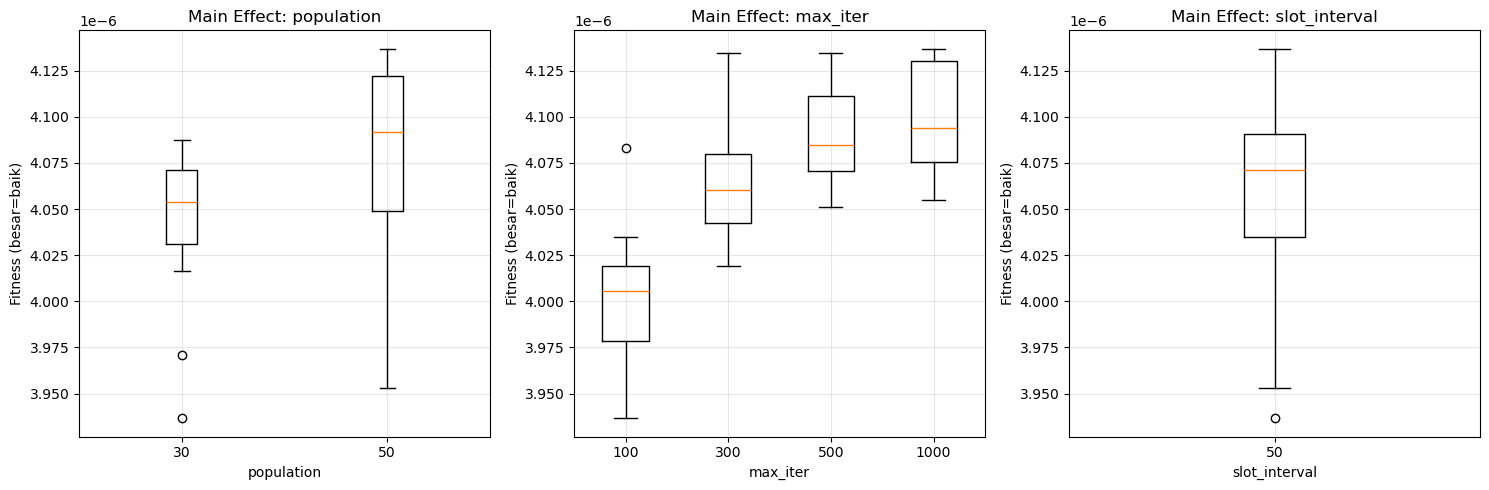

In [23]:
# Dampak relatif tiap faktor
def dampak_relatif(df, faktor, metrik='final_fitness'):
    means = df.groupby(faktor)[metrik].mean()
    return (means.max() - means.min()) / means.min() * 100.0 if means.min() > 0 else 0.0

for f in ['population', 'max_iter', 'slot_interval']:
    print(f"Dampak {f:14s} terhadap fitness: {dampak_relatif(df_detail, f):.2f}%")

# Boxplot main effect
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, f in zip(axes, ['population', 'max_iter', 'slot_interval']):
    levels = sorted(df_detail[f].unique())
    data = [df_detail[df_detail[f] == lv]['final_fitness'].values for lv in levels]
    ax.boxplot(data, labels=[str(lv) for lv in levels])
    ax.set_title(f"Main Effect: {f}")
    ax.set_xlabel(f); ax.set_ylabel("Fitness (besar=baik)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(out_path("skenario1_main_effect.png"), dpi=150)
plt.show()

## 23. Skenario 1 — Kurva Konvergensi Konfigurasi Terbaik

**(BARU).** Kurva penurunan penalty vs iterasi untuk run terbaik.

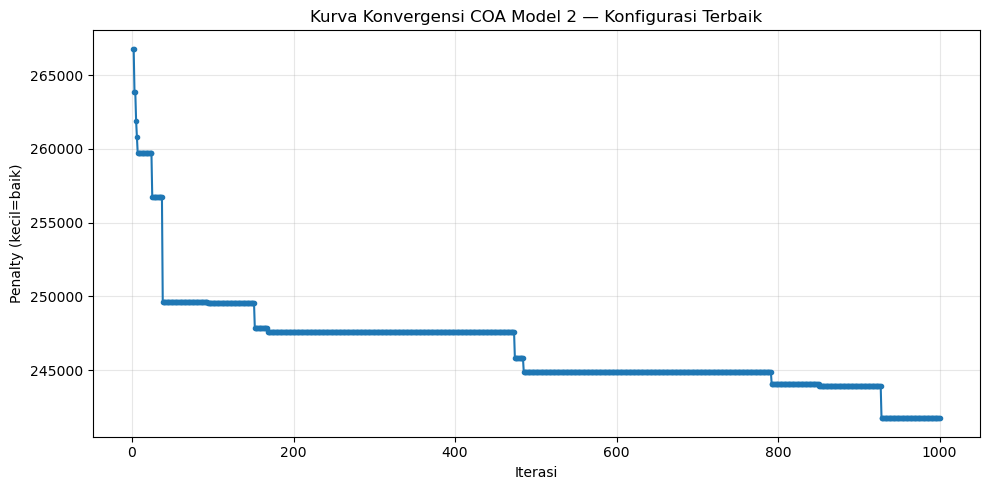

Konfigurasi terbaik: pop=50, iter=1000, int=50, seed=42


In [28]:
# Run terbaik
best_run = df_detail.loc[df_detail['final_fitness'].idxmax()]
ckpt_best = out_path(f"konvergensi_pop{int(best_run['population'])}_iter{int(best_run['max_iter'])}"
                     f"_int{int(best_run['slot_interval'])}_seed{int(best_run['seed'])}.csv")
cv = pd.read_csv(ckpt_best)
plt.figure(figsize=(10, 5))
plt.plot(cv['iterasi'], cv['penalty'], marker='.')
plt.xlabel("Iterasi"); plt.ylabel("Penalty (kecil=baik)")
plt.title("Kurva Konvergensi COA Model 2 — Konfigurasi Terbaik")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(out_path("skenario1_konvergensi.png"), dpi=150)
plt.show()
print("Konfigurasi terbaik:",
      f"pop={int(best_run['population'])}, iter={int(best_run['max_iter'])}, "
      f"int={int(best_run['slot_interval'])}, seed={int(best_run['seed'])}")

## 24. Skenario 1 — Fitness & Runtime

In [29]:
# =============================================================================
# TABEL BEST-PER-RUN → EXCEL
# Membaca detail_per_run.csv, menyusun satu baris per run (semua seed),
# menampilkan Best Fitness (normalisasi) & Execution Time (dengan 's'),
# lalu menulis ke file Excel tersendiri di folder output.
# =============================================================================
from openpyxl import Workbook                                  # menulis Excel berformat
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side

# Baca hasil detail per-run (sudah dibuat oleh cell eksperimen)
_df = pd.read_csv(DETAIL_CSV)

# Urutkan agar rapi: population -> max_iter -> seed -> interval
_df = _df.sort_values(['population', 'max_iter', 'seed', 'slot_interval']).reset_index(drop=True)

# Bentuk file Excel dengan header berwarna
_wb = Workbook(); _ws = _wb.active; _ws.title = "Best_Per_Run"
_navy  = PatternFill('solid', fgColor='1F3864')                # warna header
_white = Font(color='FFFFFF', bold=True)                       # font header putih tebal
_thin  = Side(style='thin', color='999999')                    # garis tipis
_border= Border(_thin, _thin, _thin, _thin)                    # bingkai sel
_center= Alignment(horizontal='center', vertical='center', wrap_text=True)

# Tulis header kolom
_headers = ['Population\n(n_pop)', 'Iteration\n(max_iter)', 'Seed', 'Interval',
            'Best Fitness', 'Execution Time']
for _ci, _h in enumerate(_headers, start=1):                   # kolom 1..6
    _c = _ws.cell(1, _ci, _h)
    _c.fill = _navy; _c.font = _white; _c.alignment = _center; _c.border = _border

# Tulis isi baris (satu baris per run)
_r = 2
for _, _row in _df.iterrows():
    _ws.cell(_r, 1, int(_row['population'])).alignment = _center      # populasi
    _ws.cell(_r, 2, int(_row['max_iter'])).alignment = _center       # iterasi
    _ws.cell(_r, 3, int(_row['seed'])).alignment = _center           # seed
    _ws.cell(_r, 4, int(_row['slot_interval'])).alignment = _center  # interval
    _ws.cell(_r, 5, f"{_row['final_fitness']:.8f}").alignment = _center      # fitness normalisasi
    _ws.cell(_r, 6, f"{_row['execution_time']}s").alignment = _center        # waktu + 's'
    for _col in range(1, 7):
        _ws.cell(_r, _col).border = _border                          # bingkai tiap sel
    _r += 1

# Atur lebar kolom
for _col, _w in zip('ABCDEF', [13, 13, 7, 9, 15, 15]):
    _ws.column_dimensions[_col].width = _w

# Simpan ke folder output
_XLSX = out_path("best_per_run.xlsx")
_wb.save(_XLSX)
print("Tabel best-per-run tersimpan:", _XLSX)
display(_df[['population','max_iter','seed','slot_interval','final_fitness','execution_time']].head(10))

Tabel best-per-run tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model1\best_per_run.xlsx


,population,max_iter,seed,slot_interval,final_fitness,execution_time
0,30,100,0,50,0.000004,296.77
1,30,100,1,50,0.000004,262.22
2,30,100,42,50,0.000004,261.01
3,30,100,123,50,0.000004,260.92
4,30,100,2024,50,0.000004,280.84
5,30,300,0,50,0.000004,876.71
6,30,300,1,50,0.000004,894.31
7,30,300,42,50,0.000004,899.37
8,30,300,123,50,0.000004,815.75
9,30,300,2024,50,0.000004,783.94


## 25. Skenario 2 — Elimination Rate & Residual per Constraint

**(BARU).** Dua grafik: elimination rate & mean residual tiap constraint. Menjawab RM-2. Dihitung agregat seluruh run.

,constraint,elimination_rate_%,mean_residual
0,H1_room_conflict,2.5,3.58
1,H2_lecturer_conflict,0.0,25.85
2,H3_lecturer_overload,0.0,86.00
3,H4_room_type_mismatch,100.0,0.00
4,H5_lunch_break,0.0,125.90
5,H6_class_completeness,100.0,0.00
6,S1_floor_movement,0.0,478.62


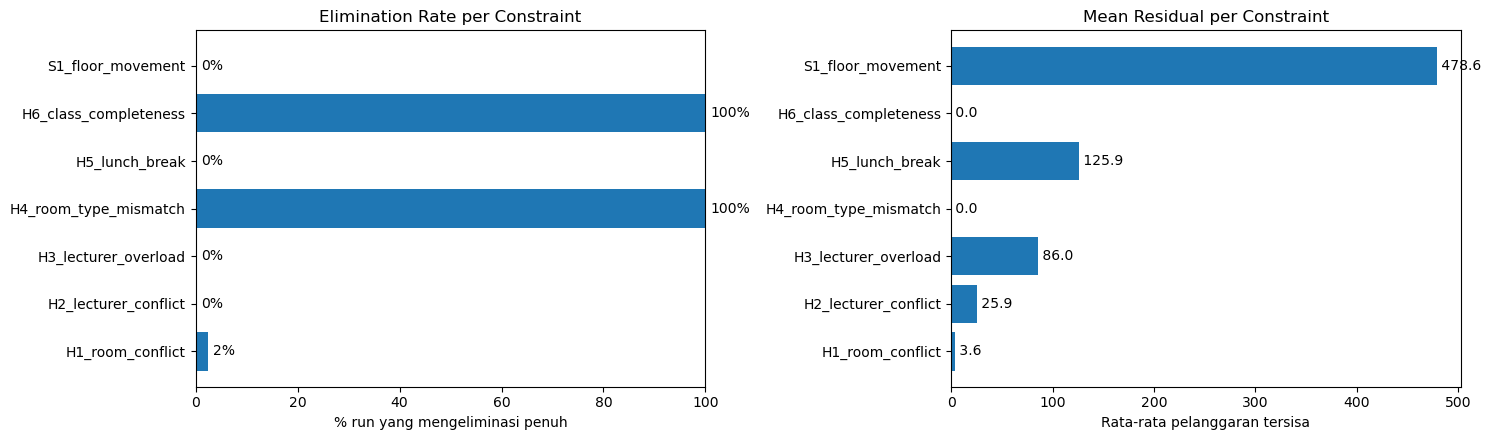

In [25]:
# Agregat elimination rate & residual lintas SEMUA run
s2 = []
for c in CONSTRAINTS:
    s2.append({'constraint': c,
               'elimination_rate_%': round((df_detail[c] == 0).mean() * 100.0, 1),
               'mean_residual': round(df_detail[c].mean(), 2)})
df_s2 = pd.DataFrame(s2)
display(df_s2)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 4.5))
axL.barh(df_s2['constraint'], df_s2['elimination_rate_%'])
axL.set_xlabel("% run yang mengeliminasi penuh"); axL.set_xlim(0, 100)
axL.set_title("Elimination Rate per Constraint")
for i, v in enumerate(df_s2['elimination_rate_%']):
    axL.text(v + 1, i, f"{v:.0f}%", va='center')
axR.barh(df_s2['constraint'], df_s2['mean_residual'])
axR.set_xlabel("Rata-rata pelanggaran tersisa")
axR.set_title("Mean Residual per Constraint")
for i, v in enumerate(df_s2['mean_residual']):
    axR.text(v, i, f" {v:.1f}", va='center')
plt.tight_layout()
fig.savefig(out_path("skenario2_constraint.png"), dpi=150)
plt.show()

## 26. Ekspor Jadwal Terbaik ke CSV

Menerjemahkan solusi terbaik keseluruhan menjadi tabel dibaca manusia dengan kolom lengkap (termasuk Gedung, Lantai, Tipe_Ruang, Kewajiban, Feasible sesuai permintaan).

In [26]:
# Bangun ulang slot pada interval run terbaik agar index slot benar
rebuild_slots(best_overall['interval'])
best_sched = best_overall['schedule']
feasible = best_overall['eval']['is_feasible']

rows = []
for k in best_sched:
    for s in k['sesi']:
        hari, jam, menit = slots_tersedia[s['slot']]
        start_min = jam * 60 + menit
        end_min = start_min + SKS_DURATION
        info = info_ruang.get(s['ruang'], {})
        rows.append({
            'Hari'       : hari,
            'Jam_Mulai'  : f"{jam:02d}:{menit:02d}",
            'Jam_Selesai': f"{end_min//60:02d}:{end_min%60:02d}",
            'Prodi'      : k['prodi'],
            'Kode_MK'    : k['kode'],
            'Kelas'      : k['kelas'],
            'Nama_MK'    : k['nama'],
            'Jenis'      : s['tipe'],
            'Ruang'      : s['ruang'],
            'Gedung'     : info.get('gedung', ''),
            'Lantai'     : info.get('lantai', ''),
            'Tipe_Ruang' : info.get('tipe', ''),
            'Dosen'      : k['dosen'],
            'SKS'        : k['sks'],
            'Kewajiban'  : k['kewajiban'],
            'Feasible'   : feasible,
        })
df_jadwal = pd.DataFrame(rows).sort_values(['Hari', 'Jam_Mulai', 'Ruang'])
JADWAL_CSV = out_path("jadwal_terbaik.csv")
df_jadwal.to_csv(JADWAL_CSV, index=False)
print("Jadwal terbaik tersimpan:", JADWAL_CSV)
display(df_jadwal.head(15))

Jadwal terbaik tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model1\jadwal_terbaik.csv


,Hari,Jam_Mulai,Jam_Selesai,Prodi,Kode_MK,Kelas,Nama_MK,Jenis,Ruang,Gedung,Lantai,Tipe_Ruang,Dosen,SKS,Kewajiban,Feasible
24,Fri,07:00,07:50,Pendidikan Teknologi Informasi,CIE61102,D,Filsafat Pendidikan dan Sains,lecture,F11.1,F,11,Kelas,103,4,1,False
221,Fri,07:00,07:50,Sistem Informasi,CIS61107,C,Manajemen Produk,lecture,F2.8,F,2,Kelas,47,3,1,False
803,Fri,07:00,07:50,Pendidikan Teknologi Informasi,CSD60712,D,Probabilitas dan Statistika,lecture,F3.13,F,3,Kelas,11,3,1,False
207,Fri,07:00,07:50,Sistem Informasi,CIS61106,A,Keamanan dan Privasi Data,lecture,F3.17,F,3,Kelas,17,2,1,False
629,Fri,07:00,07:50,Pendidikan Teknologi Informasi,COM60061,D,Capstone Project,lecture,F3.18,F,3,Kelas,76,3,1,False
786,Fri,07:00,07:50,Sistem Informasi,CSD60711,D,Perancangan Pengalaman Pengguna,lecture,F3.6,F,3,Kelas,62,3,1,False
315,Fri,07:00,07:50,Teknologi Informasi,CIT60031,A,Manajemen Proyek Teknologi Informasi,lecture,F3.9,F,3,Kelas,94,3,0,False
386,Fri,07:00,07:50,Teknologi Informasi,CIT61016,C,Data Sains,lecture,F4.3,F,4,Kelas,15,3,1,False
458,Fri,07:00,07:50,Pendidikan Teknologi Informasi,COM60014,D,Pemrograman Dasar,practicum,G1.3,G,1,Lab,75,5,1,False
125,Fri,07:00,07:50,Pendidikan Teknologi Informasi,CIE61208,A,Basis Data,practicum,G1.7,G,1,Lab,4,3,1,False


## 26. Laporan Ringkas (TXT)

**(BARU).** Ringkasan naratif kedua skenario untuk dilampirkan ke skripsi.

In [31]:
lines = []
lines.append("=== RINGKASAN EKSPERIMEN COA MODEL 2 (Greedy Initialization) ===\n")
lines.append(f"Total run: {len(df_detail)} ({len(GRID)} kombinasi x {len(SEEDS)} seed)")
lines.append("\n--- SKENARIO 1: PARAMETER ---")
for f in ['population', 'max_iter', 'slot_interval']:
    lines.append(f"Dampak {f} terhadap fitness: {dampak_relatif(df_detail, f):.2f}%")
lines.append(f"Konfigurasi terbaik: pop={int(best_run['population'])}, "
             f"iter={int(best_run['max_iter'])}, interval={int(best_run['slot_interval'])}")
lines.append("\n--- SKENARIO 2: CONSTRAINTS ---")
lines.append(f"Rata-rata penurunan penalty: {df_detail['reduction_pct'].mean():.2f}%")
lines.append(f"Run mencapai feasible: {df_detail['is_feasible'].mean()*100:.1f}%")
for _, r in df_s2.iterrows():
    lines.append(f"  {r['constraint']:24s} | elim {r['elimination_rate_%']:5.1f}% "
                 f"| residual {r['mean_residual']:.2f}")
REPORT = out_path("ringkasan_eksperimen.txt")
with open(REPORT, 'w') as f:
    f.write("\n".join(lines))
print("\n".join(lines))
print("\nLaporan tersimpan:", REPORT)

=== RINGKASAN EKSPERIMEN COA MODEL 2 (Greedy Initialization) ===

Total run: 40 (8 kombinasi x 5 seed)

--- SKENARIO 1: PARAMETER ---
Dampak population terhadap fitness: 0.81%
Dampak max_iter terhadap fitness: 2.42%
Dampak slot_interval terhadap fitness: 0.00%
Konfigurasi terbaik: pop=50, iter=1000, interval=50

--- SKENARIO 2: CONSTRAINTS ---
Rata-rata penurunan penalty: 11.19%
Run mencapai feasible: 0.0%
  H1_room_conflict         | elim   2.5% | residual 3.58
  H2_lecturer_conflict     | elim   0.0% | residual 25.85
  H3_lecturer_overload     | elim   0.0% | residual 86.00
  H4_room_type_mismatch    | elim 100.0% | residual 0.00
  H5_lunch_break           | elim   0.0% | residual 125.90
  H6_class_completeness    | elim 100.0% | residual 0.00
  S1_floor_movement        | elim   0.0% | residual 478.62

Laporan tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\SALAH\Model2\ringkasan_eksperimen.txt
